#📌 Extracción

In [2]:
import json
import pandas as pd

with open("TelecomX_Data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [7]:
df.info()
df.describe(include="all")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer.gender            7267 non-null   str    
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   str    
 5   customer.Dependents        7267 non-null   str    
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   str    
 8   phone.MultipleLines        7267 non-null   str    
 9   internet.InternetService   7267 non-null   str    
 10  internet.OnlineSecurity    7267 non-null   str    
 11  internet.OnlineBackup      7267 non-null   str    
 12  internet.DeviceProtection  7267 non-null   str    
 13  internet.TechSupport       7267 non-null   str    
 14  int

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [18]:
# df.isnull().sum()
# df.duplicated().sum()

for col in df.select_dtypes(include="object").columns:
    print(f"\nColumna: {col}")
    print(df[col].unique())



Columna: customerID
<StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 ...
 '9975-SKRNR', '9978-HYCIN', '9979-RGMZT', '9985-MWVIX', '9986-BONCE',
 '9987-LUTYD', '9992-RRAMN', '9992-UJOEL', '9993-LHIEB', '9995-HOTOH']
Length: 7267, dtype: str

Columna: Churn
<StringArray>
['No', 'Yes', '']
Length: 3, dtype: str

Columna: customer.gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Columna: customer.Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Columna: customer.Dependents
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Columna: phone.PhoneService
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Columna: phone.MultipleLines
<StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str

Columna: internet.InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Columna: internet.OnlineSecurity
<StringArray>
['No', 'Yes', 'N

C:\Users\plane\AppData\Local\Temp\ipykernel_15708\391625175.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [28]:
# df.replace('', 'No', inplace=True) # inplace=True para modificar el DataFrame original
# df.replace('No internet service', 'No', inplace=True)
df.replace('No phone service', 'No', inplace=True)
# df.replace(['No', 'No internet service'], 'No', inplace=True) # Esta línea reemplaza ambos valores en una sola llamada
for col in df.select_dtypes(include="object").columns:
    print(f"\nColumna: {col}")
    print(df[col].unique())


Columna: customerID
<StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 ...
 '9975-SKRNR', '9978-HYCIN', '9979-RGMZT', '9985-MWVIX', '9986-BONCE',
 '9987-LUTYD', '9992-RRAMN', '9992-UJOEL', '9993-LHIEB', '9995-HOTOH']
Length: 7267, dtype: str

Columna: customer.gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Columna: phone.MultipleLines
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Columna: internet.InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Columna: account.Contract
<StringArray>
['One year', 'Month-to-month', 'Two year']
Length: 3, dtype: str

Columna: account.PaymentMethod
<StringArray>
[             'Mailed check',          'Electronic check',
   'Credit card (automatic)', 'Bank transfer (automatic)']
Length: 4, dtype: str

Columna: account.Charges.Total
<StringArray>
[  '593.3',   '542.4',  '280.85', '1237.85',   '267.

C:\Users\plane\AppData\Local\Temp\ipykernel_15708\2446466155.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [29]:
# forma mas optima que encontre
for col in df.select_dtypes(include="object").columns:
    val_unicos = set(df[col].dropna().str.strip().unique())
    
    if val_unicos == {'Yes', 'No'}:
        df[col] = df[col].str.strip().map({'No': 0, 'Yes': 1})

C:\Users\plane\AppData\Local\Temp\ipykernel_15708\1318882002.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [30]:
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.60,593.3
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.4
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,0,1,0,0,One year,0,Mailed check,55.15,742.9
7263,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.7
7264,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75
7265,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65


#📊 Carga y análisis

In [38]:
df.describe(include="all") # agregando include="all" para mostrar estadísticas de columnas no numéricas
# df.mean(numeric_only=True)
# df.median(numeric_only=True)
# df.std(numeric_only=True)
# df.describe(include="object") # para obtener estadísticas de columnas de tipo objeto (categoricas) 

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
count,7267,7267.000000,7267,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267,...,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267,7267.000000,7267,7267.000000,7267
unique,7267,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,NaN,3,NaN,4,NaN,6531
top,0002-ORFBO,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,Fiber optic,...,NaN,NaN,NaN,NaN,NaN,Month-to-month,NaN,Electronic check,NaN,
freq,1,NaN,3675,NaN,NaN,NaN,NaN,NaN,NaN,3198,...,NaN,NaN,NaN,NaN,NaN,4005,NaN,2445,NaN,11
mean,NaN,0.257190,NaN,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,NaN,...,0.344571,0.342782,0.289528,0.383927,0.387505,NaN,0.593230,NaN,64.720098,NaN
std,NaN,0.437115,NaN,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,NaN,...,0.475261,0.474672,0.453575,0.486374,0.487214,NaN,0.491265,NaN,30.129572,NaN
min,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,18.250000,NaN
25%,NaN,0.000000,NaN,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,35.425000,NaN
50%,NaN,0.000000,NaN,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,NaN,70.300000,NaN
75%,NaN,1.000000,NaN,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,89.875000,NaN


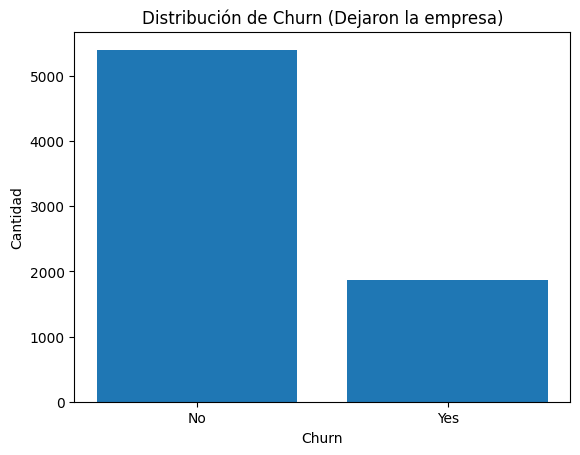

In [40]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure()
plt.bar(['No', 'Yes'], churn_counts.values)
plt.xlabel("Churn")
plt.ylabel("Cantidad")
plt.title("Distribución de Churn (Dejaron la empresa)")
plt.show()

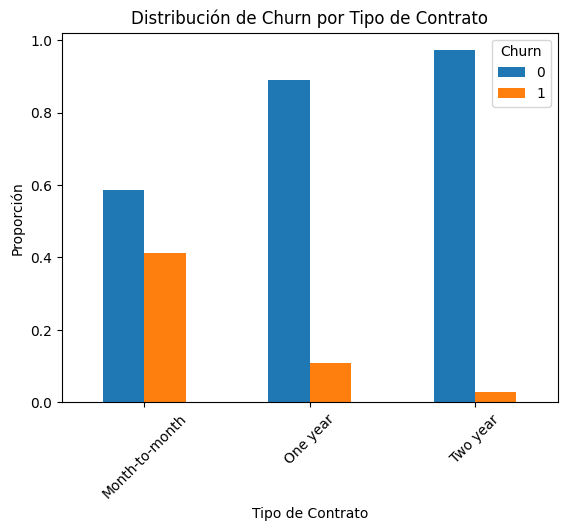

In [ ]:

ct = pd.crosstab(df['account.Contract'], df['Churn'], normalize='index')

ct.plot(kind='bar')
plt.title('Distribución de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Proporción')
plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

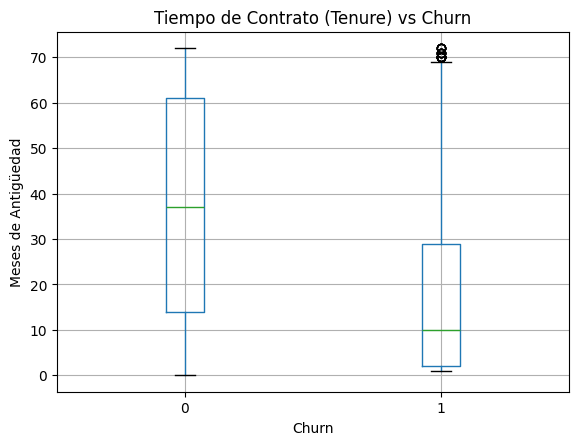

In [57]:
plt.figure()
df.boxplot(column='customer.tenure', by='Churn')
plt.title('Tiempo de Contrato (Tenure) vs Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Meses de Antigüedad')
plt.show()

<Figure size 640x480 with 0 Axes>

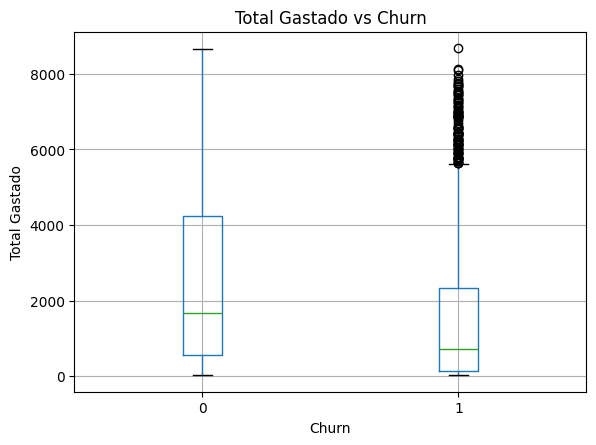

In [60]:
plt.figure()
df.boxplot(column='account.Charges.Total', by='Churn')
plt.title('Total Gastado vs Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Total Gastado')
plt.show()

#📄Informe final

Luego de realizar las consultas y generar los gráficos, se puede concluir que la mayor retención de clientes se concentra en aquellos con mayor antigüedad y con contratos de tipo anual. Por ello, la mejor estrategia para la empresa sería desarrollar promociones o nuevos modelos de servicio orientados a los clientes más recientes, quienes, con el tiempo y una atención adecuada, podrían generar una mayor fidelidad hacia la empresa